Fit-Ergebnisse:
Delta I = 93.33 ± 0.02 µA
Delta U = 10.81 ± 0.04 µV
M = 22.16 ± 0.00 pH
U0 = 102.54 µV
m = 0.000134 µV/µA


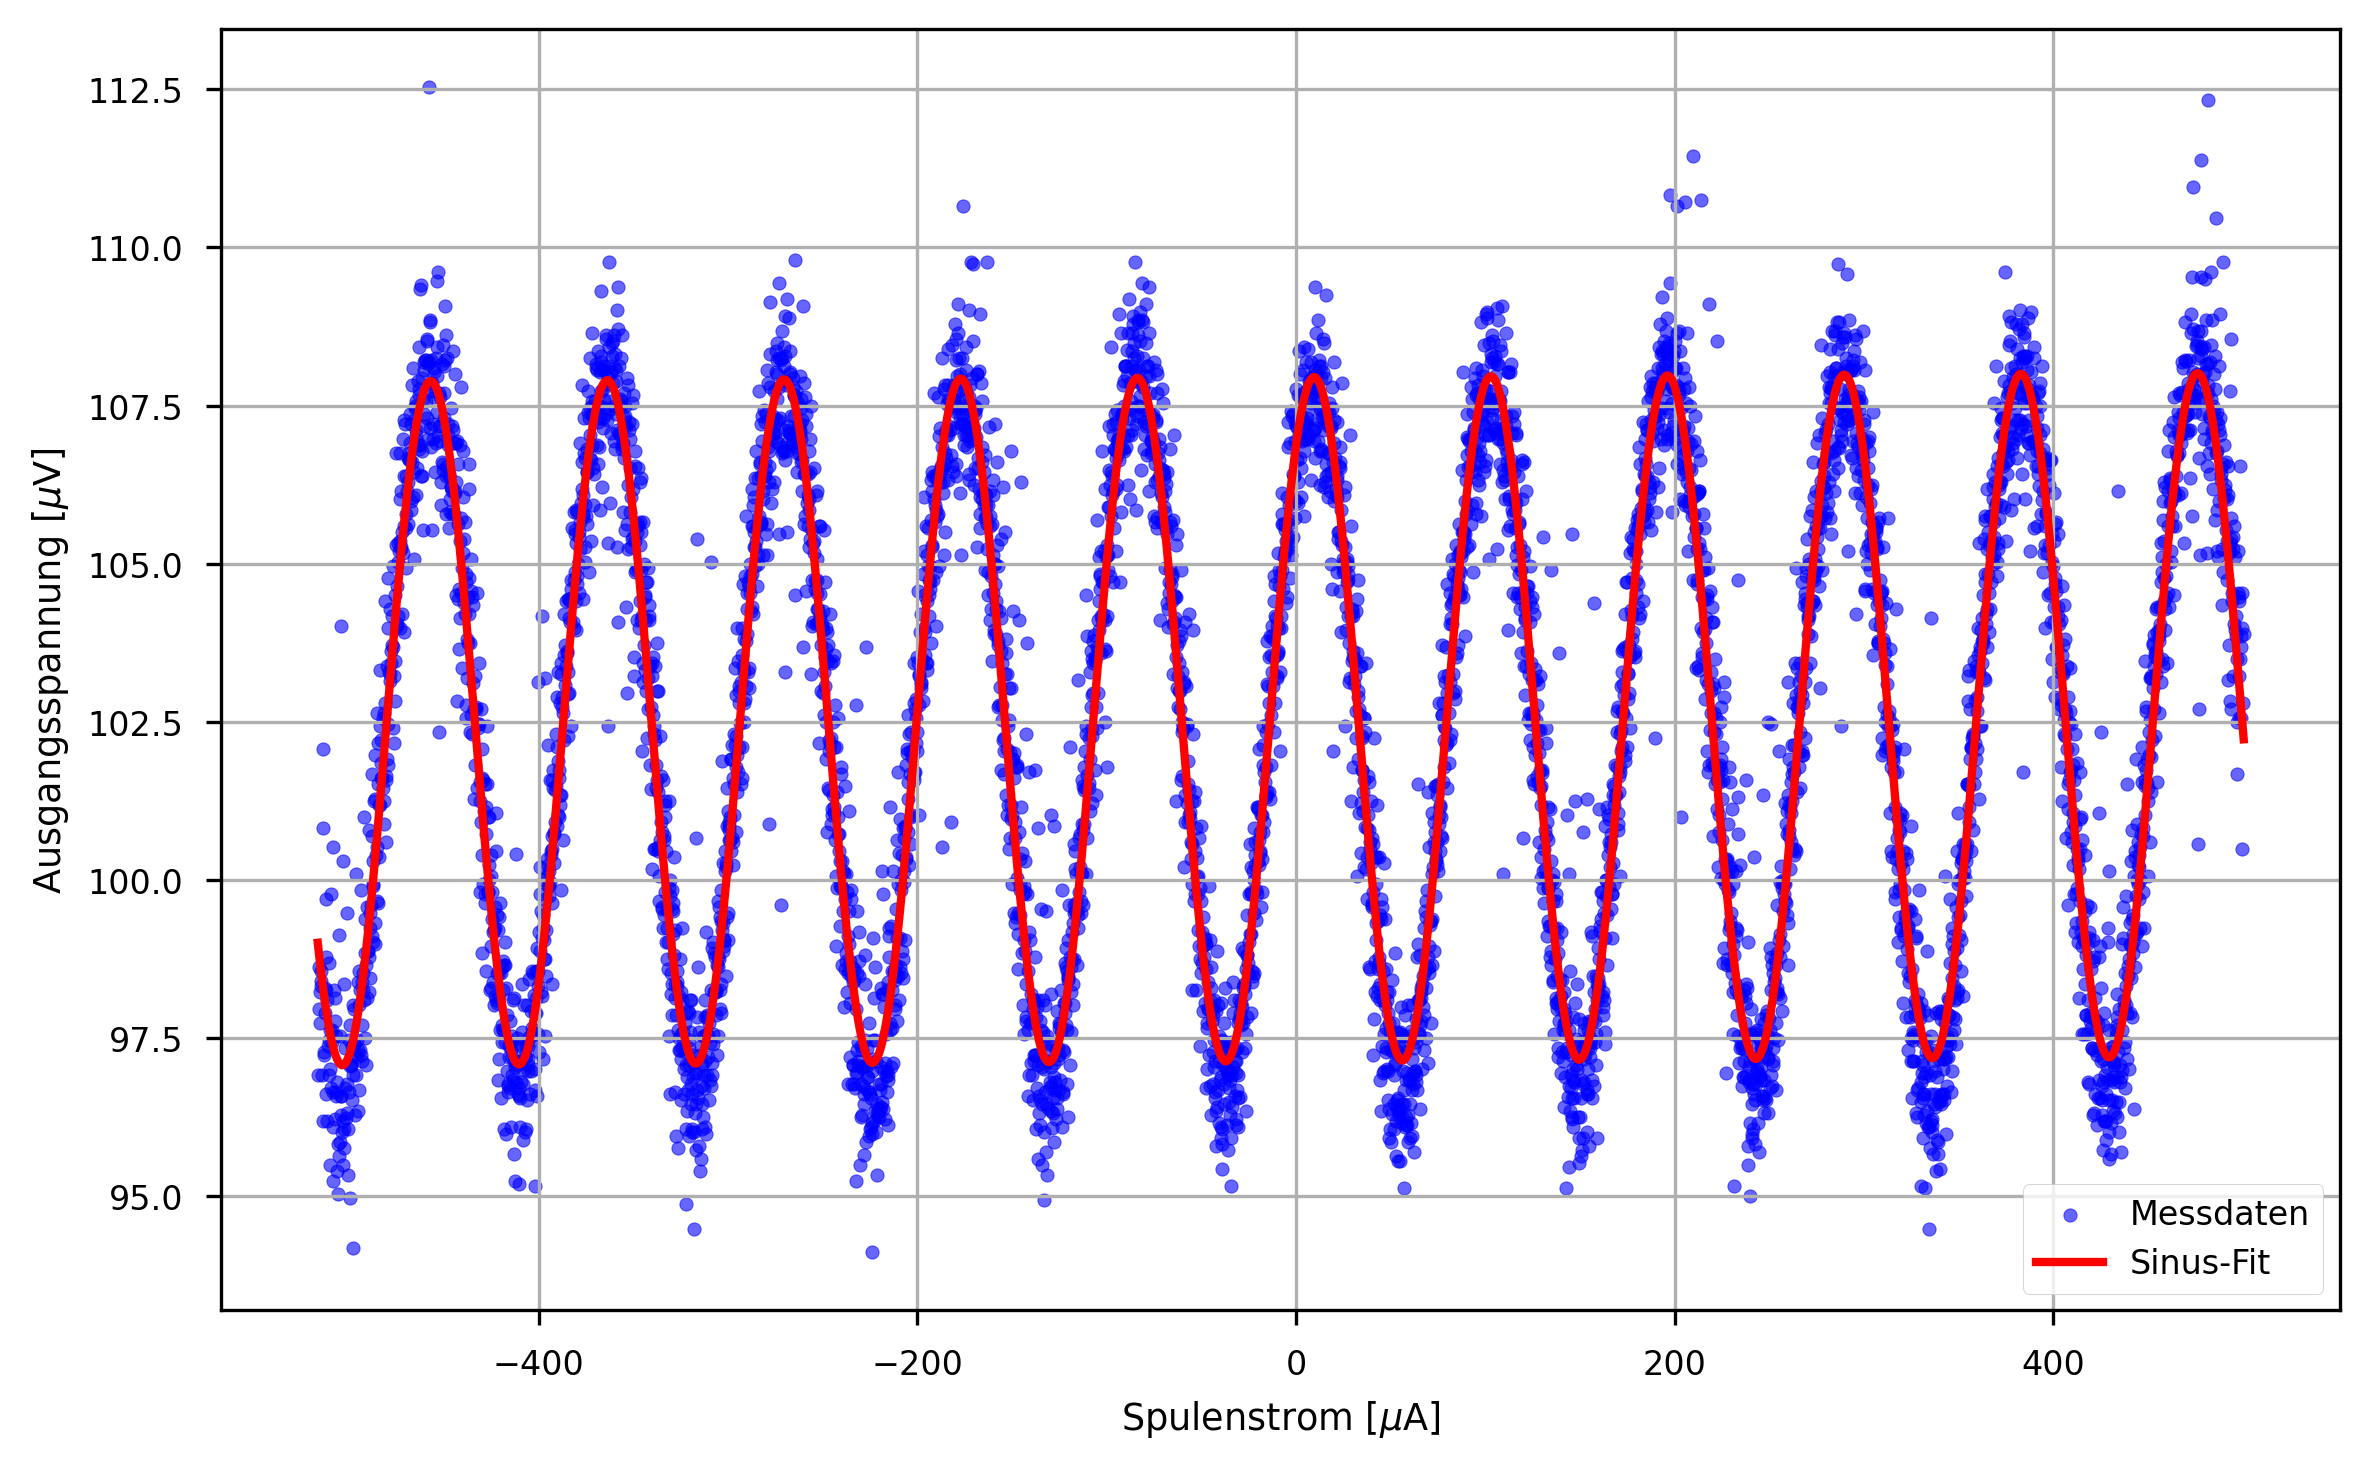

In [27]:
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.style as mtlstyle

from scipy.optimize import curve_fit

mtlstyle.use("seaborn-v0_8-paper")

rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (5, 3)

df = pd.read_csv("10_26_2011-07_43_03_FLL_1.csv")

# Daten vorbereiten
data = (
    df.rename(columns={"0_x": "I", "0_y": "U"})
      .dropna()
      .sort_values("I")
      .groupby("I", as_index=False)["U"].mean()
)

I = data["I"].to_numpy()
U = data["U"].to_numpy()

Ibar = I.mean()

# Modell: Sinus + kleiner linearer Drift
def model(I, U0, m, c, s, dI):
    w = 2 * np.pi / dI
    return U0 + m * (I - Ibar) + c * np.cos(w * I) + s * np.sin(w * I)

# Robuste Periodensuche
period_grid = np.linspace(70, 120, 5001)

rss = []
betas = []

for dI in period_grid:
    w = 2 * np.pi / dI
    X = np.column_stack([
        np.ones_like(I),
        I - Ibar,
        np.cos(w * I),
        np.sin(w * I)
    ])

    beta, *_ = np.linalg.lstsq(X, U, rcond=None)
    residuals = U - X @ beta

    rss.append(np.sum(residuals**2))
    betas.append(beta)

best_idx = np.argmin(rss)

dI0 = period_grid[best_idx]
U0_0, m0, c0, s0 = betas[best_idx]

# Feiner Fit mit curve_fit
p0 = [U0_0, m0, c0, s0, dI0]

bounds = (
    [90, -0.02, -20, -20, 70],
    [115,  0.02,  20,  20, 120]
)

popt, pcov = curve_fit(
    model,
    I,
    U,
    p0=p0,
    bounds=bounds,
    maxfev=100000
)

U0_fit, m_fit, c_fit, s_fit, Delta_I = popt
perr = np.sqrt(np.diag(pcov))

# Amplitude und Spannungsmodulation
A = np.sqrt(c_fit**2 + s_fit**2)
Delta_U = 2 * A

# Unsicherheit von Delta_U
var_c = pcov[2, 2]
var_s = pcov[3, 3]
cov_cs = pcov[2, 3]

A_err = np.sqrt(
    (c_fit / A)**2 * var_c
    + (s_fit / A)**2 * var_s
    + 2 * (c_fit * s_fit / A**2) * cov_cs
)

Delta_U_err = 2 * A_err

Delta_I_err = perr[4]

# Kopplungsinduktivität
Phi0 = 2.067833848e-15  # Vs

M = Phi0 / (Delta_I * 1e-6)
M_err = M * Delta_I_err / Delta_I

print("Fit-Ergebnisse:")
print(f"Delta I = {Delta_I:.2f} ± {Delta_I_err:.2f} µA")
print(f"Delta U = {Delta_U:.2f} ± {Delta_U_err:.2f} µV")
print(f"M = {M*1e12:.2f} ± {M_err*1e12:.2f} pH")
print(f"U0 = {U0_fit:.2f} µV")
print(f"m = {m_fit:.6f} µV/µA")

# Plot
I_fit = np.linspace(I.min(), I.max(), 3000)
U_fit = model(I_fit, *popt)

plt.figure(figsize=(8, 5))
plt.scatter(I, U, s=10, label="Messdaten", color="blue", alpha=0.6)
plt.plot(I_fit, U_fit, label="Sinus-Fit", color="red", linewidth=2)
plt.xlabel(r"Spulenstrom [$\mu$A]")
plt.ylabel(r"Ausgangsspannung [$\mu$V]")
#plt.title(r"$U_\mathrm{OUT}$-$I$-Kennlinie des DC-SQUIDs")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()